# Aura Graph RAG 품질·중심성 분석 리포트

AuraDB에 적재된 `ArxivPaper` 지식그래프를 대상으로 **준수율 · 정밀도 · ER 일관성** 세 수치를 재고,
같은 리포트에 **GDS PageRank 허브 10**과 **커뮤니티 5**를 실어 그래프의 중심과 분류 구성을 숫자로 말합니다.

| 지표 | 측정 대상 | 정의 |
|---|---|---|
| **준수율** | Aura 그래프 자체 | 스키마 규칙(식별자 형식·필수 속성·분류 정합·날짜·임베딩 차원·저자 연결)을 통과한 논문 노드, 라벨·자기참조 규칙을 통과한 관계의 비율 |
| **정밀도** | Aura 그래프 ↔ 원천 JSONL | 고정 시드(42)로 뽑은 무작위 50건에 대해 *존재 · 제목 · 주분류 · 분류집합 · 저자 · 참고관계* 6개 사실을 채점한 일치율 |
| **ER 일관성** | Aura 그래프 | 중복 식별자·필수값 누락·고아 노드·타입 오류 관계·자기참조 등 불변식 위반이 없는 비율 |
| **PageRank 허브 10** | GDS | 인용망 전체에서 PageRank 점수 상위 10개 논문 |
| **커뮤니티 5** | GDS | Leiden 커뮤니티 상위 5개의 크기·구성과 커뮤니티별 최빈 주분류 |

**참고관계 방향** — 참고문헌 원천 JSONL의 레코드 하나는 *피인용 논문*이고, 그 안의 `cit_arxiv_id`는
**그 논문을 인용한 논문**의 ID 목록입니다(적재 노트북 `arxiv_ai_kg_to_aura.ipynb` 7절과 동일).
따라서 그래프의 방향은 `(cit_arxiv_id 논문)-[:REFERENCES]->(레코드의 논문)`이고,
정밀도의 참고관계 사실은 표본 논문으로 **들어오는** REFERENCES와 대조합니다.

Aura에는 아무것도 쓰지 않습니다. GDS 계산은 임시 Aura Graph Analytics 세션에서 수행합니다
(Free 등급 인스턴스는 세션 자체가 무료입니다 — 5절에서 등급을 확인합니다).


In [41]:
from __future__ import annotations

import json, math, os, random, re, warnings
from collections import Counter
from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

AI_DIR = ROOT / "data" / "ai"
# 참고문헌 폴더 이름은 두 가지로 불려 왔습니다. 있는 쪽을 씁니다.
_REFERENCE_CANDIDATES = [
    ROOT / "data" / "ai_references" / "arxiv_ai_references_api",
    ROOT / "data" / "ai_references_api",
]
REFERENCE_DIR = next((p for p in _REFERENCE_CANDIDATES if p.exists()), _REFERENCE_CANDIDATES[0])
REPORT_DIR = ROOT / "reports"

PAPER_LABEL = "ArxivPaper"
AUTHOR_LABEL = "ArxivAuthorName"
SAMPLE_SIZE = 50
RANDOM_SEED = 42
TOP_HUBS = 10
TOP_COMMUNITIES = 5

# arxiv_id 정규화: URL이든 맨 ID든 버전(v2 등) 표기든 같은 표준형으로 모읍니다.
_NEW_ID = re.compile(
    r"(?:(?:https?://)?(?:www\.)?arxiv\.org/(?:abs|pdf)/|arxiv:)?([0-9]{4}\.[0-9]{4,5})(?:v[0-9]+)?(?:\.pdf)?$",
    re.I)
_OLD_ID = re.compile(
    r"(?:(?:https?://)?(?:www\.)?arxiv\.org/(?:abs|pdf)/|arxiv:)?([a-z-]+(?:\.[A-Z]{2})?/\d{7})(?:v[0-9]+)?(?:\.pdf)?$",
    re.I)
# Cypher `=~`는 전체 일치이므로, 위 정규화가 뱉는 표준형과 같은 문법을 검사식으로 둡니다.
ARXIV_ID_CYPHER = r"[0-9]{4}\.[0-9]{4,5}|[a-z-]+(\.[A-Z]{2})?/[0-9]{7}"


def normalize_arxiv_id(value):
    """URL·버전 표기가 섞인 원천 ID를 표준형 하나로 모읍니다. 못 알아보면 None."""
    if value is None:
        return None
    text = str(value).strip()
    for pattern in (_NEW_ID, _OLD_ID):
        m = pattern.fullmatch(text)
        if m:
            return m.group(1)
    return None


def read_jsonl(path):
    rows = []
    with path.open(encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def pct(x):
    """None/NaN은 '측정불가'로 표시합니다 — 0%과 혼동하지 않기 위해서입니다."""
    return "측정불가" if x is None or (isinstance(x, float) and math.isnan(x)) else f"{x:.4f}"


print(f"ROOT           = {ROOT}")
print(f"AI_DIR         = {AI_DIR}  (존재: {AI_DIR.exists()})")
print(f"REFERENCE_DIR  = {REFERENCE_DIR}  (존재: {REFERENCE_DIR.exists()})")


ROOT           = c:\Users\Playdata\Desktop\arxiv_graph_RAG
AI_DIR         = c:\Users\Playdata\Desktop\arxiv_graph_RAG\data\ai  (존재: True)
REFERENCE_DIR  = c:\Users\Playdata\Desktop\arxiv_graph_RAG\data\ai_references\arxiv_ai_references_api  (존재: True)


## 1. Aura 연결 및 그래프 스냅샷

`.env`는 출력하지 않고, 자격증명은 환경변수에서만 읽습니다.


In [42]:
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")
load_dotenv(ROOT / "notebooks" / ".env")

from neo4j import GraphDatabase

NEO4J_URI = os.environ["NEO4J_URI"]
NEO4J_USER = os.environ.get("NEO4J_USERNAME", os.environ.get("NEO4J_USER"))
NEO4J_PASSWORD = os.environ["NEO4J_PASSWORD"]
NEO4J_DATABASE = os.environ.get("NEO4J_DATABASE", "neo4j")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD),
                               notifications_min_severity="OFF")
driver.verify_connectivity()


def query(cypher, **params):
    records, _, _ = driver.execute_query(cypher, parameters_=params, database_=NEO4J_DATABASE)
    return [r.data() for r in records]


node_counts = query("MATCH (n) RETURN labels(n) AS labels, count(*) AS n ORDER BY n DESC")
rel_counts = query("MATCH ()-[r]->() RETURN type(r) AS relationship, count(r) AS n ORDER BY n DESC")
print("노드 라벨별:", node_counts)
print("관계 종류별:", rel_counts)


노드 라벨별: [{'labels': ['ArxivAuthorName'], 'n': 111171}, {'labels': ['ArxivPaper'], 'n': 37854}]
관계 종류별: [{'relationship': 'AUTHORED', 'n': 268928}, {'relationship': 'REFERENCES', 'n': 69438}]


## 2. 준수율 — Aura 그래프가 스키마 규칙을 지키는 비율

논문 노드 규칙 8종과 관계 규칙 2종을 Cypher로 직접 검사합니다.
규칙 이름과 검사식을 한 리스트에서 만들어 질의를 조립하므로, 통계와 규칙 설명이 서로 어긋날 수 없습니다.


In [43]:
NODE_RULES = [
    ("arxiv_id 형식",           "p.arxiv_id IS NOT NULL AND p.arxiv_id =~ $id_re"),
    ("title 존재",               "p.title IS NOT NULL AND trim(p.title) <> ''"),
    ("abstract 존재",            "p.abstract IS NOT NULL AND trim(p.abstract) <> ''"),
    ("primary_category 정합",    "p.primary_category IS NOT NULL AND p.primary_category IN p.categories"),
    ("categories 비어있지 않음",  "p.categories IS NOT NULL AND size(p.categories) > 0"),
    ("published 유효",           "p.published IS NOT NULL AND p.published <= datetime()"),
    ("embedding 차원 일치",      "p.embedding IS NOT NULL AND p.embedding_dimensions IS NOT NULL "
                                  "AND size(p.embedding) = p.embedding_dimensions"),
    ("저자 연결 존재",           f"EXISTS {{ (:{AUTHOR_LABEL})-[:AUTHORED]->(p) }}"),
]
_flags = ",\n  ".join(f"({expr}) AS r{i}" for i, (_, expr) in enumerate(NODE_RULES))
_sums = ",\n  ".join(f"sum(CASE WHEN r{i} THEN 1 ELSE 0 END) AS c{i}" for i in range(len(NODE_RULES)))
_all = " AND ".join(f"r{i}" for i in range(len(NODE_RULES)))

node_stat = query(f"""
MATCH (p:{PAPER_LABEL})
WITH p,
  {_flags}
RETURN count(*) AS total,
  {_sums},
  sum(CASE WHEN {_all} THEN 1 ELSE 0 END) AS all_ok
""", id_re=ARXIV_ID_CYPHER)[0]

rel_stat = query(f"""
CALL {{
  MATCH (s)-[r:REFERENCES]->(t)
  RETURN count(r) AS total,
         sum(CASE WHEN s:{PAPER_LABEL} AND t:{PAPER_LABEL} AND s <> t THEN 1 ELSE 0 END) AS ok
}}
WITH total AS ref_total, ok AS ref_ok
CALL {{
  MATCH (s)-[r:AUTHORED]->(t)
  RETURN count(r) AS total,
         sum(CASE WHEN s:{AUTHOR_LABEL} AND t:{PAPER_LABEL} THEN 1 ELSE 0 END) AS ok
}}
RETURN ref_total, ref_ok, total AS auth_total, ok AS auth_ok
""")[0]

node_rule_rates = {name: (node_stat[f"c{i}"] / node_stat["total"] if node_stat["total"] else float("nan"))
                    for i, (name, _) in enumerate(NODE_RULES)}
checked = node_stat["total"] + rel_stat["ref_total"] + rel_stat["auth_total"]
passed = node_stat["all_ok"] + rel_stat["ref_ok"] + rel_stat["auth_ok"]
compliance = {
    "nodes": node_stat["all_ok"] / node_stat["total"] if node_stat["total"] else float("nan"),
    "references": rel_stat["ref_ok"] / rel_stat["ref_total"] if rel_stat["ref_total"] else float("nan"),
    "authored": rel_stat["auth_ok"] / rel_stat["auth_total"] if rel_stat["auth_total"] else float("nan"),
    "overall": passed / checked if checked else float("nan"),
}

print(f"검사 대상: 논문 노드 {node_stat['total']:,} · REFERENCES {rel_stat['ref_total']:,} "
      f"· AUTHORED {rel_stat['auth_total']:,}")
print("규칙별 통과율:")
for name, rate in node_rule_rates.items():
    violation = node_stat["total"] - round(rate * node_stat["total"])
    flag = "" if rate == 1.0 else f"   ← 위반 {violation:,}건"
    print(f"  - {name:22s} {rate:.4f}{flag}")
print("준수율:", {k: pct(v) for k, v in compliance.items()})


검사 대상: 논문 노드 37,854 · REFERENCES 69,438 · AUTHORED 268,928
규칙별 통과율:
  - arxiv_id 형식            1.0000
  - title 존재               1.0000
  - abstract 존재            1.0000
  - primary_category 정합    1.0000
  - categories 비어있지 않음     1.0000
  - published 유효           1.0000
  - embedding 차원 일치        1.0000
  - 저자 연결 존재               1.0000
준수율: {'nodes': '1.0000', 'references': '1.0000', 'authored': '1.0000', 'overall': '1.0000'}


## 3. 정밀도 — 무작위 50건을 원천 JSONL 기준으로 채점

`data/ai`(seed 논문)와 `data/ai_references/.../arxiv_ai_references_api`(참고문헌 논문, part1~7만)를
모두 읽어 고유 논문 집합을 만들고, 고정 시드(42)로 50건을 뽑아 그래프와 대조합니다.

- 참고문헌 파일의 `metadata_cache` 파일은 같은 논문을 담은 옛 형식이라 제외합니다.
- `found: false`인 참고문헌 레코드는 적재 노트북에서도 건너뛰므로 여기서도 제외합니다.
- `참고관계` 사실은 원천에 `cit_arxiv_id` 필드가 있는 레코드에서만 채점하므로, 사실마다 분모가 다릅니다.


In [44]:
ai_files = sorted(AI_DIR.glob("*.jsonl")) if AI_DIR.exists() else []
ref_files = ([p for p in sorted(REFERENCE_DIR.glob("*.jsonl")) if "metadata_cache" not in p.name]
             if REFERENCE_DIR.exists() else [])
if not ai_files and not ref_files:
    raise FileNotFoundError(f"{AI_DIR} 또는 {REFERENCE_DIR}에 JSONL이 없습니다.")

source_by_id = {}
source_reference_edges = set()   # (citing_id, cited_id)
unparsable_ids, skipped_not_found, source_row_count = 0, 0, 0

for path in ai_files:
    for row in read_jsonl(path):
        source_row_count += 1
        rid = normalize_arxiv_id(row.get("id"))
        if rid is None:
            unparsable_ids += 1
            continue
        source_by_id.setdefault(rid, row)

for path in ref_files:
    for row in read_jsonl(path):
        source_row_count += 1
        if row.get("found") is False:
            skipped_not_found += 1
            continue
        rid = normalize_arxiv_id(row.get("id") or row.get("arxiv_id"))
        if rid is None:
            unparsable_ids += 1
            continue
        source_by_id.setdefault(rid, row)
        for citing_raw in row.get("cit_arxiv_id") or []:
            citing = normalize_arxiv_id(citing_raw)
            if citing and citing != rid:
                source_reference_edges.add((citing, rid))

print(f"원천 파일 {len(ai_files) + len(ref_files)}개 · 레코드 {source_row_count:,}건 "
      f"· 고유 논문 {len(source_by_id):,}건 · found=false 제외 {skipped_not_found:,}건 "
      f"· ID 파싱 실패 {unparsable_ids:,}건")

rng = random.Random(RANDOM_SEED)
candidates = sorted(source_by_id)          # 정렬로 파일 순서에 의존하지 않게 고정
rng.shuffle(candidates)
sample_ids = candidates[:min(SAMPLE_SIZE, len(candidates))]
if len(sample_ids) < SAMPLE_SIZE:
    warnings.warn(f"유효한 고유 논문이 {len(sample_ids)}건뿐입니다. {len(sample_ids)}건 표본으로 계산합니다.")

aura_rows = query(f"""
UNWIND $ids AS id
OPTIONAL MATCH (p:{PAPER_LABEL} {{arxiv_id: id}})
RETURN id,
       p IS NOT NULL AS exists,
       p.title AS title,
       p.primary_category AS primary_category,
       p.categories AS categories,
       [(p)<-[:AUTHORED]-(a:{AUTHOR_LABEL}) | a.name] AS authors,
       [(p)<-[:REFERENCES]-(c:{PAPER_LABEL}) | c.arxiv_id] AS citing
""", ids=sample_ids)
aura_by_id = {r["id"]: r for r in aura_rows}

FACTS = ["paper_exists", "title", "primary_category", "categories", "authors", "references"]
scored, passed_facts = Counter(), Counter()
sample_detail = []
for rid in sample_ids:
    src, g = source_by_id[rid], aura_by_id.get(rid, {})
    exists = bool(g.get("exists"))
    facts = {
        "paper_exists": exists,
        "title": exists and str(g.get("title") or "").strip() == str(src.get("title") or "").strip(),
        "primary_category": exists and g.get("primary_category") == src.get("primary_category"),
        "categories": exists and set(g.get("categories") or []) >= set(src.get("categories") or []),
        "authors": exists and set(src.get("authors") or []) <= set(g.get("authors") or []),
    }
    # cit_arxiv_id = "이 논문을 인용한 논문" → 그래프에서는 표본 논문으로 들어오는 REFERENCES와 대조합니다.
    if "cit_arxiv_id" in src:
        want = {normalize_arxiv_id(c) for c in (src.get("cit_arxiv_id") or [])} - {None, rid}
        facts["references"] = exists and want <= set(g.get("citing") or [])
    for fact, ok in facts.items():
        scored[fact] += 1
        passed_facts[fact] += bool(ok)
    sample_detail.append({"arxiv_id": rid, **facts})

total_scored = sum(scored.values())
total_passed = sum(passed_facts.values())
precision = total_passed / total_scored if total_scored else float("nan")
fact_precision = {f: (passed_facts[f] / scored[f] if scored[f] else None) for f in FACTS}

print(f"표본 {len(sample_ids)}건 · 시드 {RANDOM_SEED}")
print(f"정밀도: {total_passed}/{total_scored} = {pct(precision)}")
for f in FACTS:
    print(f"  - {f:17s} {passed_facts[f]:3d}/{scored[f]:3d}  {pct(fact_precision[f])}")
mismatched = [d for d in sample_detail if not all(v for k, v in d.items() if k != "arxiv_id")]
print("불일치 레코드:", [d["arxiv_id"] for d in mismatched] or "없음")


원천 파일 9개 · 레코드 38,380건 · 고유 논문 37,854건 · found=false 제외 0건 · ID 파싱 실패 0건
표본 50건 · 시드 42
정밀도: 294/294 = 1.0000
  - paper_exists       50/ 50  1.0000
  - title              50/ 50  1.0000
  - primary_category   50/ 50  1.0000
  - categories         50/ 50  1.0000
  - authors            50/ 50  1.0000
  - references         44/ 44  1.0000
불일치 레코드: 없음


## 4. ER 일관성 — 그래프 불변식 검사

중복 식별자, 필수값 누락, 고아 노드, 타입이 어긋난 관계, 자기참조 총 6종의 불변식을 검사합니다.
`arxiv_id`·저자 이름에는 Aura 쪽 유일성 제약이 이미 걸려 있으므로 중복은 0건이 정상이며,
그 제약이 실제로 살아 있는지 확인하는 용도로 남겨 둡니다.


In [45]:
er_checks = query(f"""
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE p.arxiv_id IS NULL OR trim(p.arxiv_id) = '' RETURN count(*) AS n }}
WITH n AS missing_id
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE p.title IS NULL OR trim(p.title) = '' RETURN count(*) AS n }}
WITH missing_id, n AS missing_title
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE NOT (p)<-[:AUTHORED]-(:{AUTHOR_LABEL}) RETURN count(*) AS n }}
WITH missing_id, missing_title, n AS orphan_papers
CALL {{ MATCH (a)-[r:AUTHORED]->(p) WHERE NOT a:{AUTHOR_LABEL} OR NOT p:{PAPER_LABEL} RETURN count(*) AS n }}
WITH missing_id, missing_title, orphan_papers, n AS authored_type_error
CALL {{ MATCH (s)-[r:REFERENCES]->(t) WHERE NOT s:{PAPER_LABEL} OR NOT t:{PAPER_LABEL} RETURN count(*) AS n }}
WITH missing_id, missing_title, orphan_papers, authored_type_error, n AS references_type_error
CALL {{ MATCH (p)-[r:REFERENCES]->(p) RETURN count(r) AS n }}
RETURN missing_id, missing_title, orphan_papers, authored_type_error, references_type_error,
       n AS reference_self_loops
""")[0]

duplicate_arxiv_id = query(f"""
MATCH (p:{PAPER_LABEL}) WHERE p.arxiv_id IS NOT NULL
WITH p.arxiv_id AS id, count(*) AS n WHERE n > 1
RETURN coalesce(sum(n - 1), 0) AS n
""")[0]["n"]

violations = {
    "duplicate_arxiv_id": duplicate_arxiv_id,
    "missing_id": er_checks["missing_id"],
    "missing_title": er_checks["missing_title"],
    "orphan_papers": er_checks["orphan_papers"],
    "authored_type_error": er_checks["authored_type_error"],
    "references_type_error": er_checks["references_type_error"],
    "reference_self_loops": er_checks["reference_self_loops"],
}
er_score = 1.0 - sum(bool(v) for v in violations.values()) / len(violations)
print("ER 검사 위반 건수:", violations)
print(f"ER 일관성 점수(위반 없는 불변식 비율, {len(violations)}종 기준): {er_score:.4f}")


ER 검사 위반 건수: {'duplicate_arxiv_id': 0, 'missing_id': 0, 'missing_title': 0, 'orphan_papers': 0, 'authored_type_error': 0, 'references_type_error': 0, 'reference_self_loops': 0}
ER 일관성 점수(위반 없는 불변식 비율, 7종 기준): 1.0000


## 5. GDS PageRank 허브 10 · 커뮤니티 5

AuraDB Free는 GDS를 내장하지 않으므로 임시 **Aura Graph Analytics 세션**(2GB, TTL 30분)에서 계산합니다.
원본 AuraDB에는 쓰지 않습니다.

> **재현성** — 준수율·정밀도·ER 일관성과 PageRank는 실행마다 같은 값이 나옵니다.
> Leiden에 `randomSeed`를 주면 커뮤니티 번호·크기도 재현되지만, 세션이 이를 지원하지 않으면
> 기본 설정으로 돌리며 그때는 **실행마다 커뮤니티 번호와 크기가 달라질 수 있습니다.**
> 상위 커뮤니티의 구성과 최빈 주분류는 대체로 안정적입니다.


In [46]:
from graphdatascience.session import (
    AuraAPICredentials, DbmsConnectionInfo, GdsSessions,
)
import requests

CLIENT_ID = os.environ["CLIENT_ID"]
CLIENT_SECRET = os.environ["CLIENT_SECRET"]
AURA_API = "https://api.neo4j.io"


def resolve_project_id():
    """프로젝트(테넌트)가 하나면 그것을 쓰고, 여럿이면 AURA_PROJECT_ID로 지정하게 합니다."""
    env_id = os.environ.get("AURA_PROJECT_ID") or os.environ.get("PROJECT_ID")
    if env_id:
        return env_id
    token = requests.post(f"{AURA_API}/oauth/token", auth=(CLIENT_ID, CLIENT_SECRET),
                           data={"grant_type": "client_credentials"}, timeout=30)
    token.raise_for_status()
    head = {"Authorization": f"Bearer {token.json()['access_token']}"}
    tenants = requests.get(f"{AURA_API}/v1/tenants", headers=head, timeout=30)
    tenants.raise_for_status()
    rows = tenants.json().get("data", [])
    if len(rows) != 1:
        raise ValueError(f"Aura 프로젝트가 {len(rows)}개입니다. .env에 AURA_PROJECT_ID로 하나를 지정하세요.")
    return rows[0]["id"]


def instance_is_free():
    """이 인스턴스가 Free 등급인지 확인합니다. Free가 아니면 세션 생성 전에 경고합니다."""
    token = requests.post(f"{AURA_API}/oauth/token", auth=(CLIENT_ID, CLIENT_SECRET),
                           data={"grant_type": "client_credentials"}, timeout=30)
    token.raise_for_status()
    head = {"Authorization": f"Bearer {token.json()['access_token']}"}
    host = NEO4J_URI.split("//")[-1].split(":")[0]
    instance_id = host.split(".")[0]
    listing = requests.get(f"{AURA_API}/v1/instances", headers=head, timeout=30)
    listing.raise_for_status()
    match = next((row for row in listing.json().get("data", []) if row.get("id") == instance_id), None)
    if match is None:
        return None
    detail = requests.get(f"{AURA_API}/v1/instances/{instance_id}", headers=head, timeout=30)
    kind = detail.json().get("data", {}).get("type") if detail.ok else None
    return kind in (None, "free-db") or "free" in str(match.get("name", "")).lower()


PROJECT_ID = resolve_project_id()
free_tier = instance_is_free()
if free_tier is False:
    warnings.warn("이 인스턴스는 Free 등급이 아닙니다. Aura Graph Analytics 세션은 GB-분으로 과금됩니다.")
else:
    print("인스턴스 등급: Free (세션 과금 없음)")

GDS_SESSION_NAME = os.getenv("GDS_SESSION_NAME", "arxiv_graphrag")
# 분석이 끝나면 세션을 정리합니다. 유지하려면 .env에 DELETE_GDS_SESSION=false를 지정합니다.
DELETE_GDS_SESSION = os.getenv("DELETE_GDS_SESSION", "true").strip().lower() in {"1", "true", "yes"}

gds = None
pagerank_top10, community_top5, community_rows = [], [], []
flow_matrix, community_mode = None, None
sessions = None


def node_meta(node_ids):
    """GDS nodeId(= AuraDB 내부 id)를 조회 전용 Cypher로 arxiv_id/이름으로 되읽습니다."""
    rows = query(f"""
    UNWIND $ids AS nid MATCH (n) WHERE id(n) = nid
    RETURN id(n) AS nodeId, labels(n)[0] AS label,
           coalesce(n.arxiv_id, n.name) AS key, n.title AS title
    """, ids=[int(x) for x in node_ids])
    return {int(r["nodeId"]): r for r in rows}


try:
    sessions = GdsSessions(api_credentials=AuraAPICredentials(CLIENT_ID, CLIENT_SECRET, PROJECT_ID))
    aura_instance_id = NEO4J_URI.split("//")[-1].split(".")[0]
    active_sessions = [s for s in sessions.list(instance_id=aura_instance_id)
                       if str(s.status).lower() not in {"deleted", "expired"}]
    active_session_names = {s.name for s in active_sessions}
    if active_sessions:
        print("현재 인스턴스의 활성 GDS 세션:")
        for session in active_sessions:
            print(f"  - {session.name}  ({session.status}, TTL={session.ttl})")
    if GDS_SESSION_NAME in active_session_names:
        print("기존 GDS 세션 재사용:", GDS_SESSION_NAME)
    elif free_tier and active_sessions:
        names = ", ".join(sorted(active_session_names))
        raise RuntimeError(
            f"Free 인스턴스에는 GDS 세션을 하나만 둘 수 있습니다. 활성 세션: {names}. "
            ".env의 GDS_SESSION_NAME을 기존 이름으로 맞추거나, Aura Console에서 기존 세션을 삭제하세요.")
    graph_size = query(f"""
    MATCH (p:{PAPER_LABEL}) OPTIONAL MATCH (p)-[r:REFERENCES]->()
    RETURN count(DISTINCT p) AS nodes, count(r) AS relationships
    """)[0]
    memory = sessions.estimate(node_count=graph_size["nodes"], relationship_count=graph_size["relationships"])
    print("GDS 세션 추정 메모리:", memory)

    gds = sessions.get_or_create(
        session_name=GDS_SESSION_NAME, memory=memory, ttl=timedelta(minutes=30),
        db_connection=DbmsConnectionInfo(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD), timeout=600)
    gds.verify_connectivity()

    # 이 세션은 재사용됩니다. 같은 이름의 투영이 이미 카탈로그에 있으면 지우고 다시 만듭니다.
    try:
        gds.graph.get(GDS_SESSION_NAME).drop()
        print("기존 그래프 투영을 지웠습니다:", GDS_SESSION_NAME)
    except Exception:
        pass

    # PageRank/Leiden에는 숫자 속성이 필요 없으므로 문자열 속성은 프로젝션하지 않습니다.
    G, project_result = gds.graph.project(
        GDS_SESSION_NAME,
        f"MATCH (s:{PAPER_LABEL})-[:REFERENCES]->(t:{PAPER_LABEL}) "
        "RETURN gds.graph.project.remote(s, t)")
    print("원곩 투영:", G.node_count(), "노드 /", G.relationship_count(), "관계")

    pagerank = gds.pageRank.stream(G, maxIterations=20, dampingFactor=0.85)

    # Leiden은 무방향 관계만 받습니다. REFERENCES(방향)를 별도의 무방향 관계로 바꿔 커뮤니티만 이걸로 돕니다.
    gds.graph.relationships.toUndirected(G, relationship_type="__ALL__", mutate_relationship_type="UNDIRECTED")
    try:
        leiden = gds.leiden.stream(G, relationshipTypes=["UNDIRECTED"], randomSeed=RANDOM_SEED, concurrency=1)
        community_mode = f"결정적 (randomSeed={RANDOM_SEED}, concurrency=1)"
    except Exception as exc:
        leiden = gds.leiden.stream(G, relationshipTypes=["UNDIRECTED"])
        community_mode = f"기본 설정 — 실행마다 커뮤니티 번호·크기가 달라질 수 있습니다 ({type(exc).__name__})"
    print("Leiden 실행 모드:", community_mode)

    nodes = pagerank[["nodeId", "score"]].merge(leiden[["nodeId", "communityId"]], on="nodeId")
    nodes["nodeId"] = nodes["nodeId"].astype(int)

    # --- PageRank 허브 10 ---
    hubs = nodes.sort_values("score", ascending=False).head(TOP_HUBS)
    meta = node_meta(hubs["nodeId"])
    pagerank_top10 = [{**meta.get(int(r.nodeId), {"nodeId": int(r.nodeId)}),
                        "communityId": int(r.communityId), "score": float(r.score)}
                       for r in hubs.itertuples()]

    # --- 커뮤니티 5: 크기·구성·최빈 주분류 ---
    sizes = nodes.groupby("communityId").size().sort_values(ascending=False).head(TOP_COMMUNITIES)
    top_ids = sizes.index.tolist()
    label_of = {cid: f"C{i + 1}" for i, cid in enumerate(top_ids)}
    members = nodes[nodes.communityId.isin(top_ids)]

    composition = pd.DataFrame(query("""
    UNWIND $ids AS nid MATCH (n) WHERE id(n) = nid
    RETURN id(n) AS nodeId, labels(n)[0] AS label, n.primary_category AS primary_category
    """, ids=members["nodeId"].tolist()))
    composition["nodeId"] = composition["nodeId"].astype(int)
    composition = composition.merge(members, on="nodeId")
    counts = composition.groupby(["communityId", "label"]).size().unstack(fill_value=0)
    category_counts = (composition.dropna(subset=["primary_category"])
                       .groupby(["communityId", "primary_category"]).size()
                       .rename("papers").reset_index())

    for cid in top_ids:
        category_rank = category_counts[category_counts.communityId == cid].sort_values(
            ["papers", "primary_category"], ascending=[False, True])
        category = (str(category_rank.iloc[0]["primary_category"])
                    if not category_rank.empty else "(미분류)")
        secondary_category = (str(category_rank.iloc[1]["primary_category"])
                              if len(category_rank) > 1 else None)
        category_label = (f"{category} · {secondary_category}"
                          if secondary_category else category)
        community_top5.append({"label": label_of[cid], "communityId": int(cid), "size": int(sizes[cid]),
                                "papers": int(counts.loc[cid].get(PAPER_LABEL, 0)),
                                "primary_category": category,
                                "secondary_category": secondary_category,
                                "authors": int(counts.loc[cid].get(AUTHOR_LABEL, 0))})
        community_rows.append({"label": label_of[cid], "size": int(sizes[cid]),
                                "papers": int(counts.loc[cid].get(PAPER_LABEL, 0)),
                                "authors": int(counts.loc[cid].get(AUTHOR_LABEL, 0)),
                                "primary_category": category,
                                "secondary_category": secondary_category,
                                "category_label": category_label})

    # --- 커뮤니티 간 인용 흐름 ---
    community_of = dict(zip(nodes.nodeId, nodes.communityId))
    names = [label_of[c] for c in top_ids] + ["기타"]
    flow_matrix = pd.DataFrame(0, index=names, columns=names)
    for e in query(f"MATCH (s:{PAPER_LABEL})-[:REFERENCES]->(t:{PAPER_LABEL}) RETURN id(s) AS s, id(t) AS t"):
        flow_matrix.loc[label_of.get(community_of.get(e["s"]), "기타"),
                        label_of.get(community_of.get(e["t"]), "기타")] += 1

    print(f"\nPageRank 허브 {TOP_HUBS}")
    for h in pagerank_top10:
        print(f"  {h['score']:8.2f}  {h.get('key')}  {str(h.get('title'))[:64]}")
    print(f"\n커뮤니티 {TOP_COMMUNITIES} (전체 {nodes.communityId.nunique():,}개 중)")
    for c in community_top5:
        print(f"  {c['label']} id={c['communityId']:<7} 크기 {c['size']:>6,} "
              f"(논문 {c['papers']:,} / 저자 {c['authors']:,})  주분류: {c['primary_category']}"
              + (f" · 보조분류: {c['secondary_category']}" if c['secondary_category'] else ""))
    print("\n커뮤니티 간 인용 흐름 (행=인용한 쪽, 열=인용된 쪽)")
    print(flow_matrix.to_string())
except Exception as exc:
    warnings.warn(f"GDS 분석을 건너뜁니다: {type(exc).__name__}: {exc}")


인스턴스 등급: Free (세션 과금 없음)
GDS 세션 추정 메모리: SessionMemory.m_2GB


Graph creation from Triplets: 100%|██████████| 100.0/100 [00:01<00:00, 64.79%/s, status: FINISHED]                                                                    


원곩 투영: 34896 노드 / 69438 관계


 PageRank: 100%|██████████| 100.0/100 [00:05<00:00, 12.29%/s, status: FINISHED] 
 Leiden: 100%|██████████| 100.0/100 [00:06<00:00, 13.14%/s, status: FINISHED]


Leiden 실행 모드: 결정적 (randomSeed=42, concurrency=1)

PageRank 허브 10
      3.78  2210.03629  ReAct: Synergizing Reasoning and Acting in Language Models
      1.85  2302.04761  Toolformer: Language Models Can Teach Themselves to Use Tools
      1.61  2005.11401  Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
      1.59  2306.05685  Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena
      1.56  2303.11366  Reflexion: Language Agents with Verbal Reinforcement Learning
      1.49  2304.03442  Generative Agents: Interactive Simulacra of Human Behavior
      1.44  2310.06770  SWE-bench: Can Language Models Resolve Real-World GitHub Issues?
      1.44  2402.03300  DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Op
      1.42  1706.03762  Attention Is All You Need
      1.36  2201.11903  Chain-of-Thought Prompting Elicits Reasoning in Large Language M

커뮤니티 5 (전체 171개 중)
  C1 id=48      크기  3,874 (논문 3,874 / 저자 0)  주분류: cs.AI · 보조분류: cs.CL
  C2 id=100     크기  2,

## 6. 커뮤니티 시각화

교안의 큰 그래프 읽기 방식을 따라, 결과를 두 장으로 줄여서 봅니다.

1. **커뮤니티 크기 분포** — 상위 커뮤니티를 큰 순서 막대로 세워 쏠림을 봅니다.
2. **커뮤니티 메타그래프** — 커뮤니티 하나를 점 하나로 줄입니다. 점의 크기는 논문 수, 점 안 숫자는
   논문 수, 선 굵기는 두 커뮤니티 사이의 상호 REFERENCES 인용 수입니다.

메타그래프 레이아웃은 `seed=42`로 고정합니다. 커뮤니티 번호 자체에는 의미가 없으므로,
점에는 커뮤니티 ID와 논문 수를 함께 적습니다. 분류 이름은 크기 분포의 x축에서 확인합니다.


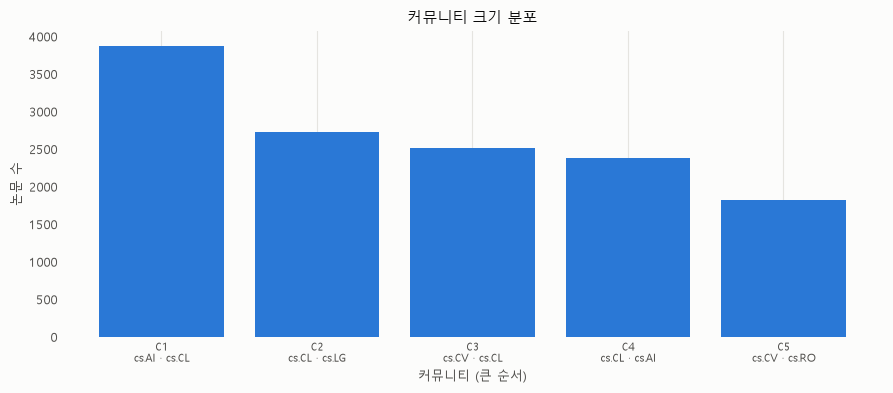

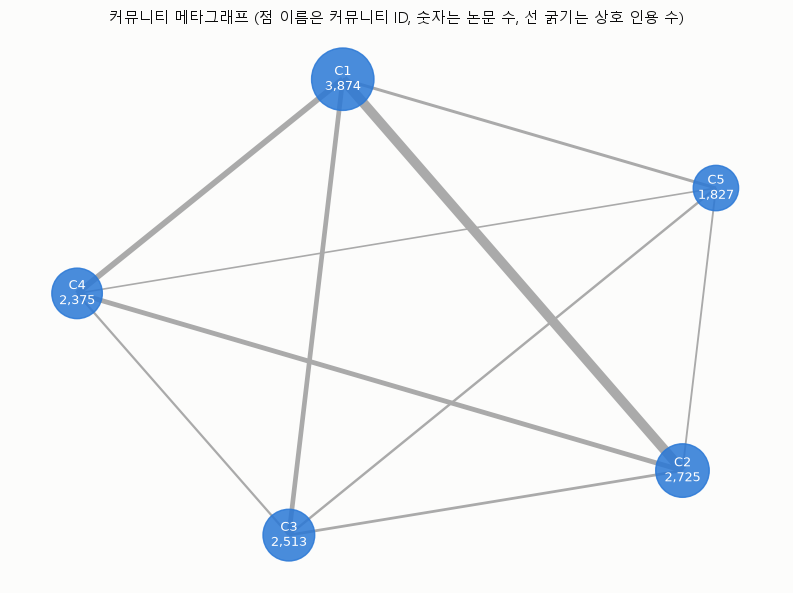

그림 저장:
  c:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_community_sizes.png
  c:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_community_metagraph.png


In [ ]:
import numpy as np
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.font_manager import fontManager

VIZ = {"surface": "#fcfcfb", "text": "#0b0b0b", "text2": "#52514e", "muted": "#8a8985",
       "grid": "#e5e4e0", "s1": "#2a78d6", "s2": "#eb6834"}
BLUES = LinearSegmentedColormap.from_list("aura_blue", [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
    "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"])

_available = {f.name for f in fontManager.ttflist}
for _font in ("Malgun Gothic", "Noto Sans KR", "NanumGothic", "AppleGothic", "Gulim"):
    if _font in _available:
        mpl.rcParams["font.family"] = _font
        break
else:
    warnings.warn("한글 폰트를 찾지 못했습니다. 그림의 한글이 깨질 수 있습니다.")
mpl.rcParams.update({"axes.unicode_minus": False, "figure.facecolor": VIZ["surface"],
                      "axes.facecolor": VIZ["surface"], "savefig.facecolor": VIZ["surface"],
                      "text.color": VIZ["text"], "axes.labelcolor": VIZ["text2"],
                      "xtick.color": VIZ["text2"], "ytick.color": VIZ["text2"], "font.size": 9})


def _bare(ax):
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    ax.xaxis.grid(True, color=VIZ["grid"], linewidth=0.8)
    ax.set_axisbelow(True)


def _short(s, n=42):
    s = " ".join(str(s or "").split())
    return s if len(s) <= n else s[:n - 1] + "…"


def _legacy_overview_plot(rows, flow, path):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(14.5, 5.4), gridspec_kw={"width_ratios": [1.25, 1]})
    y = np.arange(len(rows))[::-1]
    papers = np.array([r["papers"] for r in rows], float)
    authors = np.array([r["authors"] for r in rows], float)
    axA.barh(y, papers, height=.46, color=VIZ["s1"], edgecolor=VIZ["surface"], linewidth=1.4, label="논문")
    axA.barh(y, authors, height=.46, left=papers, color=VIZ["s2"], edgecolor=VIZ["surface"],
             linewidth=1.4, label="저자")
    total = float((papers + authors).sum())
    xmax = float((papers + authors).max()) * 1.34
    for yi, p, a in zip(y, papers, authors):
        axA.text(p + a + total * 0.006, yi, f"{int(p + a):,}  ({(p + a) / total:.0%})",
                  va="center", ha="left", fontsize=9, color=VIZ["text2"])
        if p > xmax * 0.062:
            axA.text(p / 2, yi, f"{int(p):,}", va="center", ha="center", fontsize=8.5, color="white")
        if a > xmax * 0.062:
            axA.text(p + a / 2, yi, f"{int(a):,}", va="center", ha="center", fontsize=8.5, color="white")
    axA.set_yticks(y)
    axA.set_yticklabels([f"{r['label']}\n{_short(r['hub_title'], 34)}" for r in rows], fontsize=8.5)
    axA.set_xlim(0, xmax)
    axA.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    axA.set_xlabel("노드 수", fontsize=9)
    axA.set_title(f"상위 {len(rows)}개 커뮤니티의 크기 구성", fontsize=11.5, color=VIZ["text"], pad=12, loc="left")
    axA.legend(frameon=False, ncol=2, loc="lower right", fontsize=9)
    _bare(axA)

    M = flow.values.astype(float)
    im = axB.imshow(np.where(M > 0, M, np.nan), cmap=BLUES,
                     norm=LogNorm(vmin=max(M[M > 0].min(), 1), vmax=M.max()) if M[M > 0].size else None)
    axB.set_xticks(range(len(flow.columns))); axB.set_xticklabels(flow.columns, fontsize=9)
    axB.set_yticks(range(len(flow.index)));   axB.set_yticklabels(flow.index, fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            color = "white" if (M[i, j] > 0 and im.norm(M[i, j]) > 0.55) else VIZ["text2"]
            axB.text(j, i, f"{int(M[i, j]):,}", ha="center", va="center", fontsize=8, color=color)
    axB.set_xlabel("인용된 커뮤니티 →", fontsize=9)
    axB.set_ylabel("← 인용한 커뮤니티", fontsize=9)
    axB.set_title("커뮤니티 간 인용 흐름 (REFERENCES, 색=로그 스케일)", fontsize=11.5,
                   color=VIZ["text"], pad=12, loc="left")
    for s in axB.spines.values():
        s.set_visible(False)
    axB.tick_params(length=0)
    cb = fig.colorbar(im, ax=axB, fraction=.03, pad=.02, shrink=.82)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, labelsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


def _legacy_hubs_plot(panels, path, top_n=4):
    panels = [p for p in panels if p["papers"]]
    if not panels:
        return None
    fig, axes = plt.subplots(len(panels), 1, figsize=(11.5, 0.6 * top_n * len(panels)), sharex=True)
    axes = np.atleast_1d(axes)
    values = [q["score"] for p in panels for q in p["papers"][:top_n]]
    lo, hi = min(values), max(values)
    for ax, p in zip(axes, panels):
        items = p["papers"][:top_n]
        y = np.arange(len(items))[::-1]
        xs = [q["score"] for q in items]
        ax.hlines(y, lo * 0.72, xs, color=VIZ["grid"], linewidth=1.6, zorder=1)
        ax.scatter(xs, y, s=58, color=VIZ["s1"], zorder=2, edgecolor=VIZ["surface"], linewidth=1.2)
        for yi, q in zip(y, items):
            ax.text(q["score"] * 1.13, yi, f"{q['score']:.2f}", va="center", ha="left",
                     fontsize=8.5, color=VIZ["text2"])
        ax.set_yticks(y)
        ax.set_yticklabels([f"{q['arxiv_id']}  {_short(q['title'], 52)}" for q in items], fontsize=8.5)
        ax.set_ylim(-0.7, len(items) - 0.3)
        ax.set_xscale("log"); ax.set_xlim(lo * 0.7, hi * 2.6)
        # 지수 표기(mathtext)는 한글 폰트에 없는 위첨자 글리프를 쓰므로, 일반 숫자로 바꿉니다.
        ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
        ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
        ax.set_title(f"{p['label']} · {p['size']:,}개 노드", fontsize=10, color=VIZ["text"], loc="left", pad=6)
        _bare(ax)
    axes[-1].set_xlabel("PageRank 점수 (로그 축, 모든 커뮤니티 공통)", fontsize=9)
    axes[0].annotate(f"커뮤니티별 PageRank 대표 논문 상위 {top_n}개", xy=(0, 1), xycoords="axes fraction",
                      xytext=(0, 34), textcoords="offset points", fontsize=11.5, color=VIZ["text"], va="bottom")
    fig.tight_layout(); fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


def plot_community_size_distribution(rows, path):
    ordered = sorted(rows, key=lambda row: row["size"], reverse=True)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(range(len(ordered)), [row["size"] for row in ordered], color=VIZ["s1"])
    ax.set_xticks(range(len(ordered)))
    ax.set_xticklabels([f"{row['label']}\n{row['category_label']}" for row in ordered], fontsize=8)
    ax.set_xlabel("커뮤니티 (큰 순서)")
    ax.set_ylabel("논문 수")
    ax.set_title("커뮤니티 크기 분포")
    _bare(ax)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


def plot_community_metagraph(rows, flow, path):
    meta = nx.Graph()
    for row in rows:
        meta.add_node(row["label"], papers=int(row["size"]))
    labels = list(meta.nodes)
    for i, source in enumerate(labels):
        for target in labels[i + 1:]:
            citations = int(flow.loc[source, target]) + int(flow.loc[target, source])
            if citations:
                meta.add_edge(source, target, citations=citations)

    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(meta, seed=42, k=1.2)
    sizes = [meta.nodes[node]["papers"] for node in meta.nodes]
    largest_size = max(sizes, default=1)
    node_sizes = [220 + 1800 * size / largest_size for size in sizes]
    citations = [meta.edges[edge]["citations"] for edge in meta.edges]
    largest_flow = max(citations, default=1)
    nx.draw_networkx_edges(meta, pos, ax=ax, edge_color="#AAAAAA",
                           width=[1 + 6 * value / largest_flow for value in citations])
    nx.draw_networkx_nodes(meta, pos, ax=ax, node_color=VIZ["s1"],
                           node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_labels(meta, pos, ax=ax, font_size=9, font_color="white",
                            labels={node: f"{node}\n{meta.nodes[node]['papers']:,}편" for node in meta.nodes})
    ax.set_title("커뮤니티 메타그래프 (점 이름은 커뮤니티 ID, 숫자는 논문 수, 선 굵기는 상호 인용 수)")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


REPORT_DIR.mkdir(exist_ok=True)
FIG_SIZE = REPORT_DIR / "aura_community_sizes.png"
FIG_META = REPORT_DIR / "aura_community_metagraph.png"
figure_paths = []
if community_rows and flow_matrix is not None:
    plot_community_size_distribution(community_rows, FIG_SIZE)
    plot_community_metagraph(community_rows, flow_matrix, FIG_META)
    figure_paths = [str(FIG_SIZE), str(FIG_META)]
    plt.show()
    print("그림 저장:", *figure_paths, sep="\n  ")
else:
    warnings.warn("GDS 결과가 없어 커뮤니티 시각화를 건너뜁니다.")


## 7. 리포트 저장과 정리

In [48]:
report = {
    "generated_at": datetime.now().astimezone().isoformat(timespec="seconds"),
    "source_files": {"ai": [str(p) for p in ai_files], "references_api": [str(p) for p in ref_files]},
    "metrics": {
        "compliance_rate": compliance,
        "compliance_rules": node_rule_rates,
        "precision": None if math.isnan(precision) else precision,
        "precision_by_fact": fact_precision,
        "precision_sample_size": len(sample_ids),
        "precision_seed": RANDOM_SEED,
        "er_consistency": er_score,
    },
    "er_violations": violations,
    "community_mode": community_mode,
    "pagerank_top10": pagerank_top10,
    "communities_top5": community_top5,
    "community_citation_flow": flow_matrix.to_dict() if flow_matrix is not None else None,
    "figures": figure_paths,
}
REPORT_DIR.mkdir(exist_ok=True)
out_path = REPORT_DIR / "aura_graph_rag_quality_report.json"
out_path.write_text(json.dumps(report, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

print("=== Aura Graph RAG 품질 리포트 ===")
print(f"준수율(그래프 전체): {pct(compliance['overall'])}   [노드 {pct(compliance['nodes'])} · "
      f"REFERENCES {pct(compliance['references'])} · AUTHORED {pct(compliance['authored'])}]")
print(f"정밀도: {pct(precision)}  ({len(sample_ids)}건 표본 · {total_scored}개 사실 · seed={RANDOM_SEED})")
print(f"ER 일관성: {er_score:.4f}")
print(f"PageRank 허브: {len(pagerank_top10)}개 / 커뮤니티: {len(community_top5)}개 / 그림 {len(figure_paths)}장")
print("JSON 저장:", out_path)

# 투영은 세션 내부 메모리에만 있으며, 세션은 기본적으로 재사용합니다(TTL 30분 후 자동 종료).
if DELETE_GDS_SESSION and sessions is not None:
    sessions.delete(session_name=GDS_SESSION_NAME)
    print("GDS 세션 삭제:", GDS_SESSION_NAME)
elif sessions is not None:
    print("GDS 세션 유지:", GDS_SESSION_NAME, "(DELETE_GDS_SESSION=false로 설정하면 유지합니다.)")
driver.close()


=== Aura Graph RAG 품질 리포트 ===
준수율(그래프 전체): 1.0000   [노드 1.0000 · REFERENCES 1.0000 · AUTHORED 1.0000]
정밀도: 1.0000  (50건 표본 · 294개 사실 · seed=42)
ER 일관성: 1.0000
PageRank 허브: 10개 / 커뮤니티: 5개 / 그림 2장
JSON 저장: c:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_graph_rag_quality_report.json
GDS 세션 삭제: arxiv_graphrag
